In [1]:
# ONLY RUN THIS IF YOU'RE IN GOOGLE COLAB
from google.colab import drive
import os

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Thesis/Pintu-Air')

# Verify you're in the right place
!pwd
!ls -la

Mounted at /content/drive
/content/drive/MyDrive/Thesis/Pintu-Air
total 24843
-rw------- 1 root root 5517847 Jun 11 14:58 '01 Result Data Cleaning Part 1.csv'
-rw------- 1 root root 1964974 Jun 11 14:58 '02 Data Preperation.ipynb'
-rw------- 1 root root  256098 Jun 11 14:58 '02 X_test.csv'
-rw------- 1 root root 4831129 Jun 11 14:58 '02 X_train.csv'
-rw------- 1 root root   40580 Jun 11 14:58 '02 y_test.csv'
-rw------- 1 root root  770651 Jun 11 14:58 '02 y_train.csv'
-rw------- 1 root root  322748 Jun 11 14:58 '03 ARIMA.ipynb'
-rw------- 1 root root    2277 Jun 11 14:58  03_Result_ARIMA.csv
-rw------- 1 root root 6247212 Jun 11 14:58  04c_ARIMA_Manggarai.ipynb
-rw------- 1 root root  631448 Jun 11 14:58  06_DataPreperation_ML.ipynb
-rw------- 1 root root 1611961 Jun 11 14:58  07a_best_model.keras
-rw------- 1 root root  371715 Jun 11 14:58  07a_LSTM_Manggarai.ipynb
-rw------- 1 root root 1685693 Jun 11 14:58  07b_best_model.keras
-rw------- 1 root root  368771 Jun 11 14:58  07b_LSTM_M

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set style and random seed
plt.style.use('default')
np.random.seed(42)

In [3]:
X_train = pd.read_csv('06_X_train_significant.csv', index_col='Tanggal', parse_dates=True)
X_test = pd.read_csv('06_X_test_significant.csv', index_col='Tanggal', parse_dates=True)
y_train = pd.read_csv('04_y_train.csv', index_col='Tanggal', parse_dates=True).squeeze()
y_test = pd.read_csv('04_y_test.csv', index_col='Tanggal', parse_dates=True).squeeze()

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\ny_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nFeatures: {list(X_train.columns)}")


X_train shape: (33972, 57)
X_test shape: (1788, 57)

y_train shape: (33972,)
y_test shape: (1788,)

Features: ['time_index', 'hour_sin', 'hour_cos', 'dayofyear_sin', 'dayofyear_cos', 'manggarai_air_lag1', 'manggarai_air_lag2', 'manggarai_air_lag3', 'manggarai_air_lag4', 'manggarai_air_lag5', 'manggarai_air_lag6', 'manggarai_air_lag7', 'manggarai_air_lag9', 'manggarai_air_lag12', 'manggarai_air_lag14', 'manggarai_air_lag15', 'manggarai_air_lag17', 'manggarai_air_lag20', 'manggarai_air_lag21', 'depok_air_lag3', 'depok_air_lag6', 'depok_air_lag7', 'depok_air_lag8', 'depok_air_lag9', 'depok_air_lag10', 'depok_air_lag12', 'depok_air_lag13', 'depok_air_lag14', 'depok_air_lag16', 'depok_air_lag19', 'depok_air_lag20', 'depok_air_lag23', 'depok_air_lag24', 'katulampa_air_lag3', 'katulampa_air_lag4', 'katulampa_air_lag5', 'katulampa_air_lag14', 'katulampa_air_lag19', 'katulampa_air_lag21', 'manggarai_cuaca_lag1_hujan', 'manggarai_cuaca_lag2_hujan', 'manggarai_cuaca_lag4_hujan', 'manggarai_cuaca

# Baseline Model

In [4]:
fixed_params = {
    'tree_method': 'gpu_hist',
    'gpu_id': 0,
    'objective': 'reg:squarederror',
    'n_jobs': -1,
    'random_state': 42,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

results = []


start_time = datetime.now()

# Train Baseline
model_base = xgb.XGBRegressor(**fixed_params)
model_base.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

training_time = datetime.now() - start_time
training_time_sec = training_time.total_seconds() 

# Hitung Metrik Baseline
base_train_pred = model_base.predict(X_train)
base_test_pred = model_base.predict(X_test)

b_tr_rmse = np.sqrt(mean_squared_error(y_train, base_train_pred))
b_tr_mae = mean_absolute_error(y_train, base_train_pred)
b_tr_mape = mean_absolute_percentage_error(y_train, base_train_pred)
b_tr_r2 = r2_score(y_train, base_train_pred)

b_te_rmse = np.sqrt(mean_squared_error(y_test, base_test_pred))
b_te_mae = mean_absolute_error(y_test, base_test_pred)
b_te_mape = mean_absolute_percentage_error(y_test, base_test_pred)
b_te_r2 = r2_score(y_test, base_test_pred)

# Simpan Baseline
results.append({
    'learning_rate': 'BASELINE',
    'n_estimators': 'BASELINE',
    'max_depth': 'BASELINE',
    
    # Masukkan Waktu Training
    'training_time_sec': round(training_time_sec, 4),
    
    'train_rmse': round(b_tr_rmse, 8),
    'train_mae': round(b_tr_mae, 8),
    'train_mape': round(b_tr_mape, 8),
    'train_r2': round(b_tr_r2, 8),
    'test_rmse': round(b_te_rmse, 8),
    'test_mae': round(b_te_mae, 8),
    'test_mape': round(b_te_mape, 8),
    'test_r2': round(b_te_r2, 8)
})

In [5]:
results

[{'learning_rate': 'BASELINE',
  'n_estimators': 'BASELINE',
  'max_depth': 'BASELINE',
  'training_time_sec': 3.9643,
  'train_rmse': np.float64(8.53243647),
  'train_mae': 2.93847906,
  'train_mape': 0.00739906,
  'train_r2': 0.9630002,
  'test_rmse': np.float64(30.89913386),
  'test_mae': 12.11296547,
  'test_mape': 0.02144645,
  'test_r2': -2.06982222}]

# Hyperparameter Tuning

In [6]:
# Parameter yang akan diubah-ubah (Grid)
param_learning_rate = [0.05, 0.1, 0.2]
param_n_estimators = [30]
param_max_depth = [6, 7, 8]

In [7]:
len(param_learning_rate) * len(param_n_estimators) * len(param_max_depth)

9

In [8]:
total_combinations = len(param_learning_rate) * len(param_n_estimators) * len(param_max_depth)
counter = 0

for lr in param_learning_rate:
    for n_est in param_n_estimators:
        for depth in param_max_depth:
            counter += 1
            
            # Gabungkan parameter fixed dengan parameter loop saat ini
            current_params = fixed_params.copy()
            current_params['learning_rate'] = lr
            current_params['n_estimators'] = n_est
            current_params['max_depth'] = depth
            
            print(f"[{counter}/{total_combinations}] Training: lr={lr}, n_est={n_est}, depth={depth}")
            
            # --- Mulai Timer Loop ---
            loop_start_time = datetime.now()
            
            # Train Model
            model = xgb.XGBRegressor(**current_params)
            model.fit(
                X_train, y_train,
                eval_set=[(X_test, y_test)],
                verbose=False
            )
            
            # --- Stop Timer Loop ---
            loop_training_time = datetime.now() - loop_start_time
            loop_time_sec = loop_training_time.total_seconds()
            
            # Predict
            train_pred = model.predict(X_train)
            test_pred = model.predict(X_test)
            
            # Calculate Metrics (Train)
            tr_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
            tr_mae = mean_absolute_error(y_train, train_pred)
            tr_mape = mean_absolute_percentage_error(y_train, train_pred)
            tr_r2 = r2_score(y_train, train_pred)
            
            # Calculate Metrics (Test)
            te_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
            te_mae = mean_absolute_error(y_test, test_pred)
            te_mape = mean_absolute_percentage_error(y_test, test_pred)
            te_r2 = r2_score(y_test, test_pred)
            
            # Append to results
            results.append({
                'learning_rate': lr,
                'n_estimators': n_est,
                'max_depth': depth,
                
                # Masukkan Waktu Training
                'training_time_sec': round(loop_time_sec, 4),
                
                'train_rmse': round(tr_rmse, 8),
                'train_mae': round(tr_mae, 8),
                'train_mape': round(tr_mape, 8),
                'train_r2': round(tr_r2, 8),
                'test_rmse': round(te_rmse, 8),
                'test_mae': round(te_mae, 8),
                'test_mape': round(te_mape, 8),
                'test_r2': round(te_r2, 8)
            })

[1/9] Training: lr=0.05, n_est=30, depth=6
[2/9] Training: lr=0.05, n_est=30, depth=7
[3/9] Training: lr=0.05, n_est=30, depth=8
[4/9] Training: lr=0.1, n_est=30, depth=6
[5/9] Training: lr=0.1, n_est=30, depth=7
[6/9] Training: lr=0.1, n_est=30, depth=8
[7/9] Training: lr=0.2, n_est=30, depth=6
[8/9] Training: lr=0.2, n_est=30, depth=7
[9/9] Training: lr=0.2, n_est=30, depth=8


In [9]:
results

[{'learning_rate': 'BASELINE',
  'n_estimators': 'BASELINE',
  'max_depth': 'BASELINE',
  'training_time_sec': 3.9643,
  'train_rmse': np.float64(8.53243647),
  'train_mae': 2.93847906,
  'train_mape': 0.00739906,
  'train_r2': 0.9630002,
  'test_rmse': np.float64(30.89913386),
  'test_mae': 12.11296547,
  'test_mape': 0.02144645,
  'test_r2': -2.06982222},
 {'learning_rate': 0.05,
  'n_estimators': 30,
  'max_depth': 6,
  'training_time_sec': 0.76,
  'train_rmse': np.float64(17.71056102),
  'train_mae': 8.93337682,
  'train_mape': 0.02143482,
  'train_r2': 0.84058914,
  'test_rmse': np.float64(15.991143),
  'test_mae': 7.02641641,
  'test_mape': 0.01389087,
  'test_r2': 0.17779592},
 {'learning_rate': 0.05,
  'n_estimators': 30,
  'max_depth': 7,
  'training_time_sec': 0.711,
  'train_rmse': np.float64(16.71248986),
  'train_mae': 8.75591001,
  'train_mape': 0.02062891,
  'train_r2': 0.85804994,
  'test_rmse': np.float64(15.92555662),
  'test_mae': 6.93865308,
  'test_mape': 0.0137570

In [10]:
df_results = pd.DataFrame(results)
df_results.to_csv('13_XGBoost_reduced_GridSearch_Results2.csv', index=False)

# Best Model

In [ ]:
final_params = fixed_params.copy()
final_params['learning_rate'] = 0.03
final_params['n_estimators'] = 200
final_params['max_depth'] = 8

model = xgb.XGBRegressor(**final_params)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False  # Supaya tidak nyampah di layar
)

# Buat Prediksi untuk Evaluasi
test_pred = model.predict(X_test)
residuals_test = y_test - test_pred
test_r2 = r2_score(y_test, test_pred)

In [23]:
model_filename = 'best_xgboost_full.json'
model.save_model(model_filename)


Most Important Features:
                    feature  importance
         manggarai_air_lag1    0.550635
         manggarai_air_lag2    0.142594
         manggarai_air_lag3    0.030738
 manggarai_cuaca_lag4_hujan    0.029388
         manggarai_air_lag4    0.029097
             depok_air_lag7    0.019065
 manggarai_cuaca_lag5_hujan    0.014571
                   hour_sin    0.012962
katulampa_cuaca_lag13_hujan    0.012892
             depok_air_lag8    0.012155
         manggarai_air_lag5    0.011835
                 time_index    0.010464
                   hour_cos    0.010237
             depok_air_lag6    0.009658
    depok_cuaca_lag10_hujan    0.009334
     depok_cuaca_lag6_hujan    0.009075
katulampa_cuaca_lag11_hujan    0.008703
            depok_air_lag10    0.008023
     depok_cuaca_lag8_hujan    0.007778
             depok_air_lag9    0.006642
 manggarai_cuaca_lag2_hujan    0.006562
         manggarai_air_lag7    0.006255
         manggarai_air_lag6    0.005974
        katula

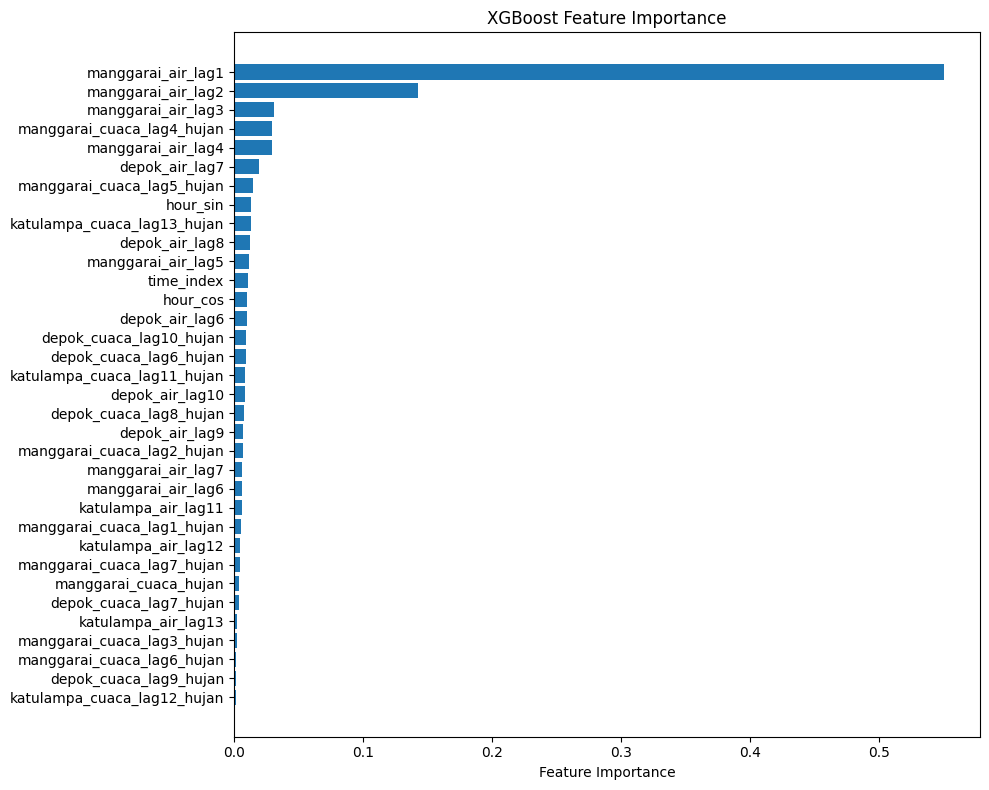

In [24]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nMost Important Features:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 8))
top_features = feature_importance
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

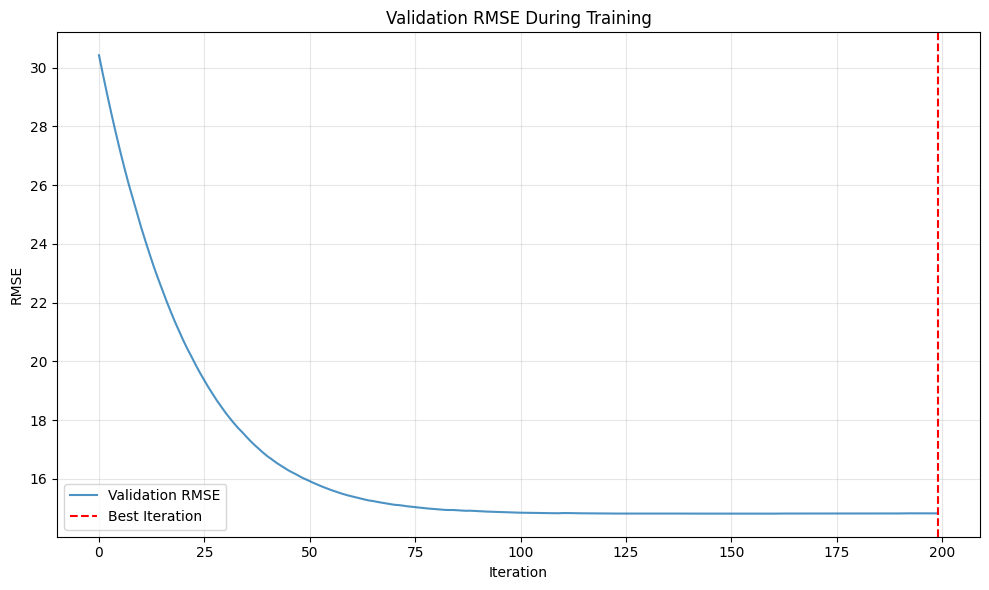

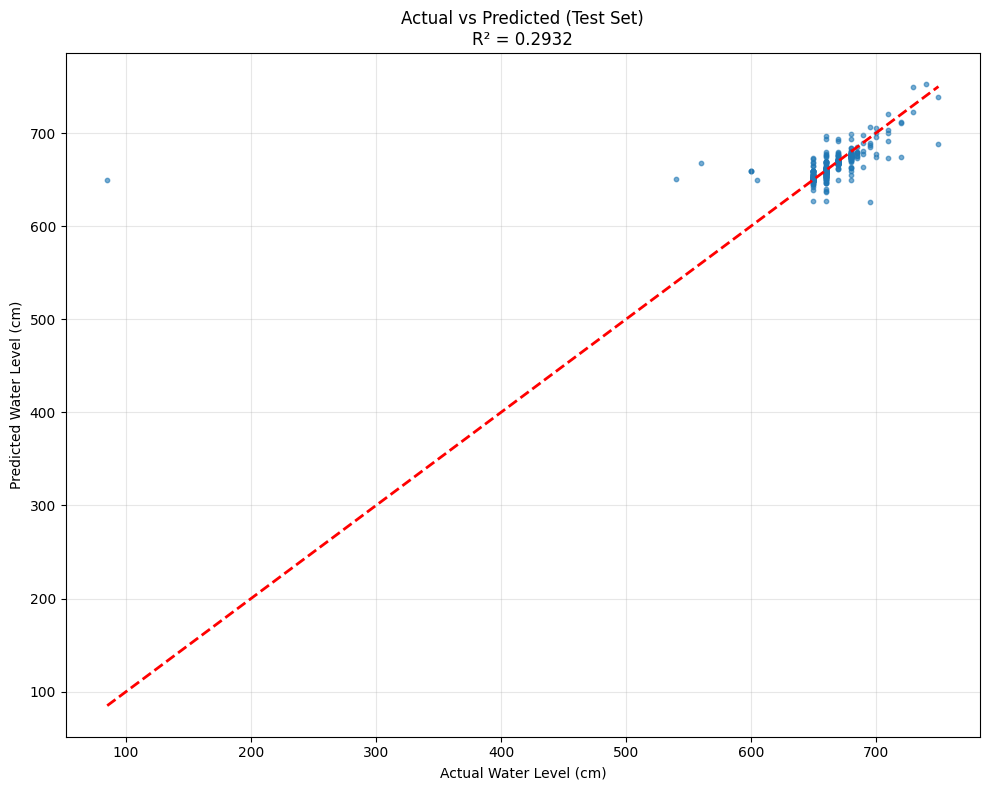

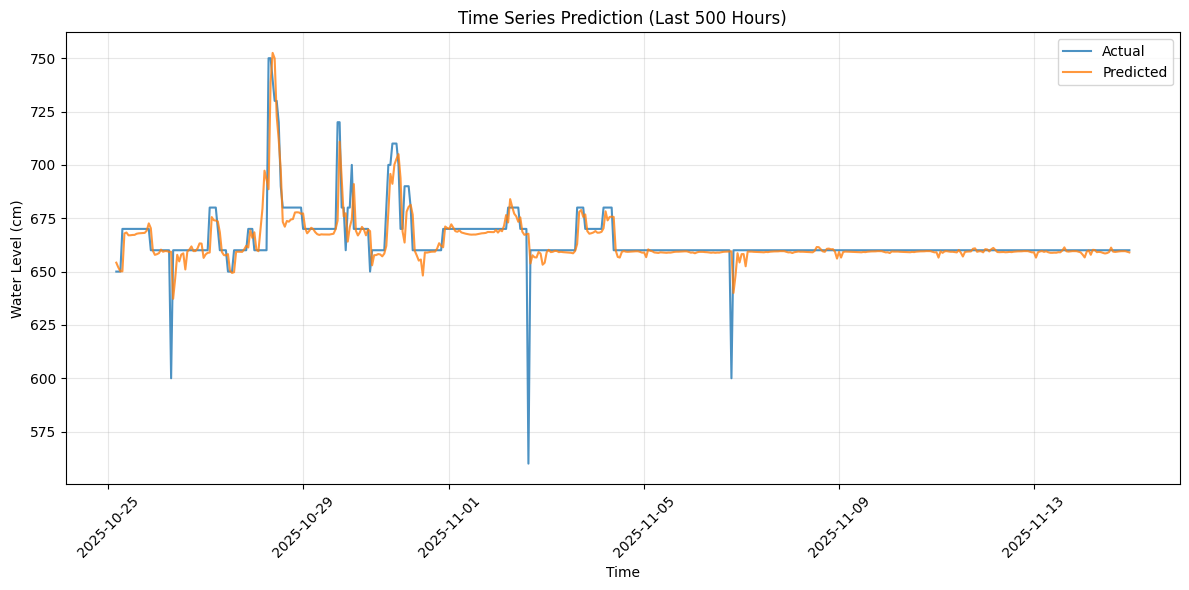

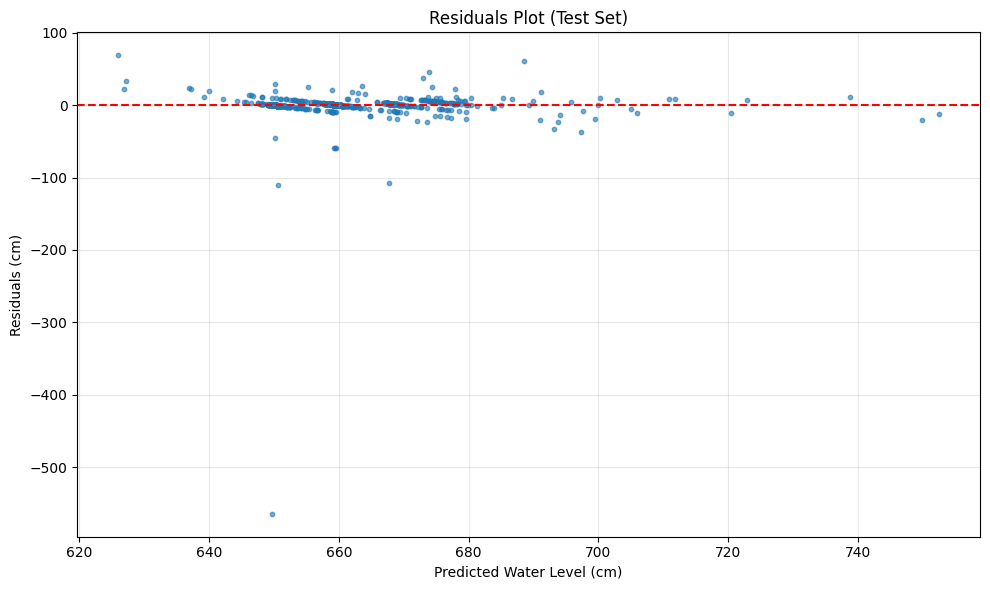

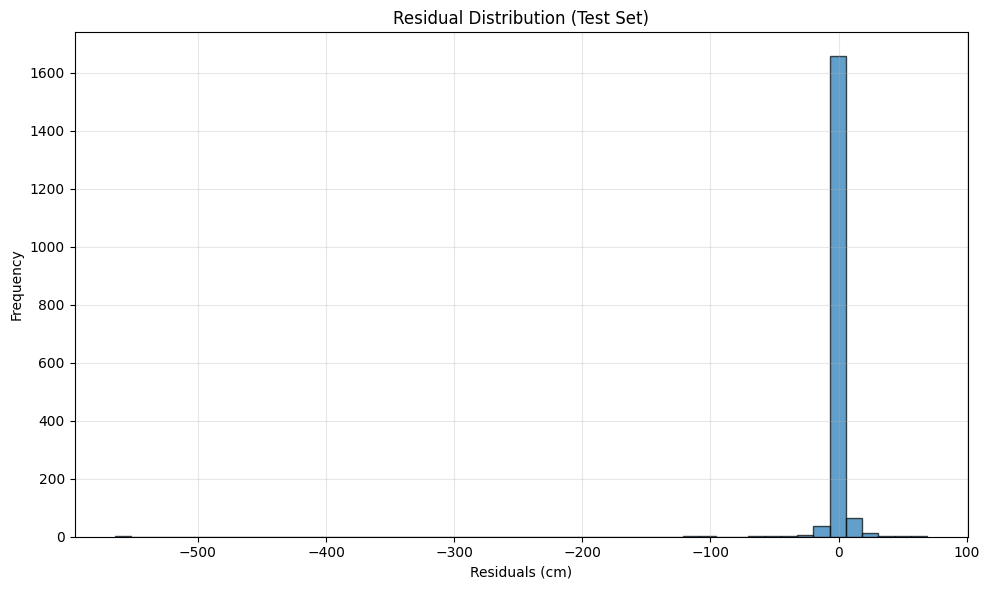

In [25]:
# --- PLOT 1: Training Validation Curve ---
plt.figure(figsize=(10, 6))
eval_results = model.evals_result()
if 'validation_0' in eval_results:
    plt.plot(eval_results['validation_0']['rmse'], label='Validation RMSE', alpha=0.8)
    # XGBoost best_iteration hanya tersedia jika early_stopping_rounds diaktifkan
    # Jika tidak, kita ambil iterasi terakhir
    best_iter = model.best_iteration if hasattr(model, 'best_iteration') else final_params['n_estimators'] - 1
    
    plt.axvline(x=best_iter, color='red', linestyle='--', label='Best Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('RMSE')
    plt.title('Validation RMSE During Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Training progress\nnot available',
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Training Progress')

plt.tight_layout()
plt.show()

# --- PLOT 2: Actual vs Predicted (Test Set) ---
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test_pred, alpha=0.6, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Water Level (cm)')
plt.ylabel('Predicted Water Level (cm)')
plt.title(f'Actual vs Predicted (Test Set)\nR² = {test_r2:.4f}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PLOT 3: Time Series Prediction (Last 500 Points) ---
plt.figure(figsize=(12, 6))
plot_points = min(500, len(y_test))
plt.plot(y_test.tail(plot_points), label='Actual', linewidth=1.5, alpha=0.8)
plt.plot(y_test.tail(plot_points).index, test_pred[-plot_points:],
         label='Predicted', linewidth=1.5, alpha=0.8)
plt.xlabel('Time')
plt.ylabel('Water Level (cm)')
plt.title(f'Time Series Prediction (Last {plot_points} Hours)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- PLOT 4: Residuals Plot ---
plt.figure(figsize=(10, 6))
plt.scatter(test_pred, residuals_test, alpha=0.6, s=10)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Water Level (cm)')
plt.ylabel('Residuals (cm)')
plt.title('Residuals Plot (Test Set)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PLOT 5: Residuals Histogram ---
plt.figure(figsize=(10, 6))
plt.hist(residuals_test, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals (cm)')
plt.ylabel('Frequency')
plt.title('Residual Distribution (Test Set)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Reduced Dataset

In [26]:
exog_columns = [
    'manggarai_air_lag1', 'manggarai_air_lag2','manggarai_air_lag3','manggarai_air_lag4','manggarai_air_lag5','manggarai_cuaca_lag4_hujan', 'manggarai_cuaca_lag5_hujan', 'depok_air_lag7','depok_air_lag8', 'hour_sin', 'hour_cos', 'time_index', 'katulampa_cuaca_lag13_hujan'
]

X_train_reduced = X_train[exog_columns]
X_test_reduced = X_test[exog_columns]

print(X_train_reduced.head())
print(X_test_reduced.head())

                     manggarai_air_lag1  manggarai_air_lag2  \
Tanggal                                                       
2021-10-17 00:00:00               565.0               565.0   
2021-10-17 01:00:00               590.0               565.0   
2021-10-17 02:00:00               575.0               590.0   
2021-10-17 03:00:00               570.0               575.0   
2021-10-17 04:00:00               565.0               570.0   

                     manggarai_air_lag3  manggarai_air_lag4  \
Tanggal                                                       
2021-10-17 00:00:00               565.0               600.0   
2021-10-17 01:00:00               565.0               565.0   
2021-10-17 02:00:00               565.0               565.0   
2021-10-17 03:00:00               590.0               565.0   
2021-10-17 04:00:00               575.0               590.0   

                     manggarai_air_lag5  manggarai_cuaca_lag4_hujan  \
Tanggal                                      

## Baseline Model

In [27]:
fixed_params = {
    'tree_method': 'gpu_hist',
    'gpu_id': 0,
    'objective': 'reg:squarederror',
    'n_jobs': -1,
    'random_state': 42,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

results_reduced = []

baseline_params = fixed_params.copy()
baseline_params['learning_rate'] = 0.1 
baseline_params['n_estimators'] = 100
baseline_params['max_depth'] = 6

start_time = datetime.now()

# Train Baseline
model_base = xgb.XGBRegressor(**baseline_params)
model_base.fit(
    X_train_reduced, y_train,
    eval_set=[(X_test_reduced, y_test)],
    verbose=False
)

training_time = datetime.now() - start_time
training_time_sec = training_time.total_seconds() 

# Hitung Metrik Baseline
base_train_pred = model_base.predict(X_train_reduced)
base_test_pred = model_base.predict(X_test_reduced)

b_tr_rmse = np.sqrt(mean_squared_error(y_train, base_train_pred))
b_tr_mae = mean_absolute_error(y_train, base_train_pred)
b_tr_mape = mean_absolute_percentage_error(y_train, base_train_pred)
b_tr_r2 = r2_score(y_train, base_train_pred)

b_te_rmse = np.sqrt(mean_squared_error(y_test, base_test_pred))
b_te_mae = mean_absolute_error(y_test, base_test_pred)
b_te_mape = mean_absolute_percentage_error(y_test, base_test_pred)
b_te_r2 = r2_score(y_test, base_test_pred)

# Simpan Baseline
results_reduced.append({
    'learning_rate': 'BASELINE (0.1)',
    'n_estimators': 'BASELINE (100)',
    'max_depth': 'BASELINE (6)',
    
    # Masukkan Waktu Training
    'training_time_sec': round(training_time_sec, 4),
    
    'train_rmse': round(b_tr_rmse, 8),
    'train_mae': round(b_tr_mae, 8),
    'train_mape': round(b_tr_mape, 8),
    'train_r2': round(b_tr_r2, 8),
    'test_rmse': round(b_te_rmse, 8),
    'test_mae': round(b_te_mae, 8),
    'test_mape': round(b_te_mape, 8),
    'test_r2': round(b_te_r2, 8)
})

In [28]:
results_reduced

[{'learning_rate': 'BASELINE (0.1)',
  'n_estimators': 'BASELINE (100)',
  'max_depth': 'BASELINE (6)',
  'training_time_sec': 1.3901,
  'train_rmse': np.float64(13.25840069),
  'train_mae': 3.23478346,
  'train_mape': 0.00993144,
  'train_r2': 0.91066214,
  'test_rmse': np.float64(14.88316778),
  'test_mae': 2.13656551,
  'test_mape': 0.00649845,
  'test_r2': 0.28778458}]

# Hyperparameter Tuning

In [29]:
# Parameter yang akan diubah-ubah (Grid)
param_learning_rate = [0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 0.2]
param_n_estimators = [50, 100, 200, 500, 1000, 2000, 3000]
param_max_depth = [3, 4, 5, 6, 7, 8, 9, 10]

In [30]:
len(param_learning_rate) * len(param_n_estimators) * len(param_max_depth)

392

In [32]:
total_combinations = len(param_learning_rate) * len(param_n_estimators) * len(param_max_depth)
counter = 0

for lr in param_learning_rate:
    for n_est in param_n_estimators:
        for depth in param_max_depth:
            counter += 1
            
            # Gabungkan parameter fixed dengan parameter loop saat ini
            current_params = fixed_params.copy()
            current_params['learning_rate'] = lr
            current_params['n_estimators'] = n_est
            current_params['max_depth'] = depth
            
            print(f"[{counter}/{total_combinations}] Training: lr={lr}, n_est={n_est}, depth={depth}")
            
            # --- Mulai Timer Loop ---
            loop_start_time = datetime.now()
            
            # Train Model
            model = xgb.XGBRegressor(**current_params)
            model.fit(
                X_train, y_train,
                eval_set=[(X_test, y_test)],
                verbose=False
            )
            
            # --- Stop Timer Loop ---
            loop_training_time = datetime.now() - loop_start_time
            loop_time_sec = loop_training_time.total_seconds()
            
            # Predict
            train_pred = model.predict(X_train)
            test_pred = model.predict(X_test)
            
            # Calculate Metrics (Train)
            tr_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
            tr_mae = mean_absolute_error(y_train, train_pred)
            tr_mape = mean_absolute_percentage_error(y_train, train_pred)
            tr_r2 = r2_score(y_train, train_pred)
            
            # Calculate Metrics (Test)
            te_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
            te_mae = mean_absolute_error(y_test, test_pred)
            te_mape = mean_absolute_percentage_error(y_test, test_pred)
            te_r2 = r2_score(y_test, test_pred)
            
            # Append to results
            results_reduced.append({
                'learning_rate': lr,
                'n_estimators': n_est,
                'max_depth': depth,
                
                # Masukkan Waktu Training
                'training_time_sec': round(loop_time_sec, 4),
                
                'train_rmse': round(tr_rmse, 8),
                'train_mae': round(tr_mae, 8),
                'train_mape': round(tr_mape, 8),
                'train_r2': round(tr_r2, 8),
                'test_rmse': round(te_rmse, 8),
                'test_mae': round(te_mae, 8),
                'test_mape': round(te_mape, 8),
                'test_r2': round(te_r2, 8)
            })

[1/392] Training: lr=0.001, n_est=50, depth=3
[2/392] Training: lr=0.001, n_est=50, depth=4
[3/392] Training: lr=0.001, n_est=50, depth=5
[4/392] Training: lr=0.001, n_est=50, depth=6
[5/392] Training: lr=0.001, n_est=50, depth=7
[6/392] Training: lr=0.001, n_est=50, depth=8
[7/392] Training: lr=0.001, n_est=50, depth=9
[8/392] Training: lr=0.001, n_est=50, depth=10
[9/392] Training: lr=0.001, n_est=100, depth=3
[10/392] Training: lr=0.001, n_est=100, depth=4
[11/392] Training: lr=0.001, n_est=100, depth=5
[12/392] Training: lr=0.001, n_est=100, depth=6
[13/392] Training: lr=0.001, n_est=100, depth=7
[14/392] Training: lr=0.001, n_est=100, depth=8
[15/392] Training: lr=0.001, n_est=100, depth=9
[16/392] Training: lr=0.001, n_est=100, depth=10
[17/392] Training: lr=0.001, n_est=200, depth=3
[18/392] Training: lr=0.001, n_est=200, depth=4
[19/392] Training: lr=0.001, n_est=200, depth=5
[20/392] Training: lr=0.001, n_est=200, depth=6
[21/392] Training: lr=0.001, n_est=200, depth=7
[22/392

In [1]:
df_results_reduced = pd.DataFrame(results_reduced)
df_results_reduced.to_csv('02_03_XGBoost_GridSearch_Results_reduced.csv', index=False)

NameError: name 'pd' is not defined

# Best Model

In [ ]:
final_params = fixed_params.copy()
final_params['learning_rate'] = 0.03
final_params['n_estimators'] = 200
final_params['max_depth'] = 8

model = xgb.XGBRegressor(**final_params)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False  # Supaya tidak nyampah di layar
)

# Buat Prediksi untuk Evaluasi
test_pred = model.predict(X_test)
residuals_test = y_test - test_pred
test_r2 = r2_score(y_test, test_pred)

In [ ]:
model_filename = 'best_xgboost_full.json'
model.save_model(model_filename)


Most Important Features:
                    feature  importance
         manggarai_air_lag1    0.550635
         manggarai_air_lag2    0.142594
         manggarai_air_lag3    0.030738
 manggarai_cuaca_lag4_hujan    0.029388
         manggarai_air_lag4    0.029097
             depok_air_lag7    0.019065
 manggarai_cuaca_lag5_hujan    0.014571
                   hour_sin    0.012962
katulampa_cuaca_lag13_hujan    0.012892
             depok_air_lag8    0.012155
         manggarai_air_lag5    0.011835
                 time_index    0.010464
                   hour_cos    0.010237
             depok_air_lag6    0.009658
    depok_cuaca_lag10_hujan    0.009334
     depok_cuaca_lag6_hujan    0.009075
katulampa_cuaca_lag11_hujan    0.008703
            depok_air_lag10    0.008023
     depok_cuaca_lag8_hujan    0.007778
             depok_air_lag9    0.006642
 manggarai_cuaca_lag2_hujan    0.006562
         manggarai_air_lag7    0.006255
         manggarai_air_lag6    0.005974
        katula

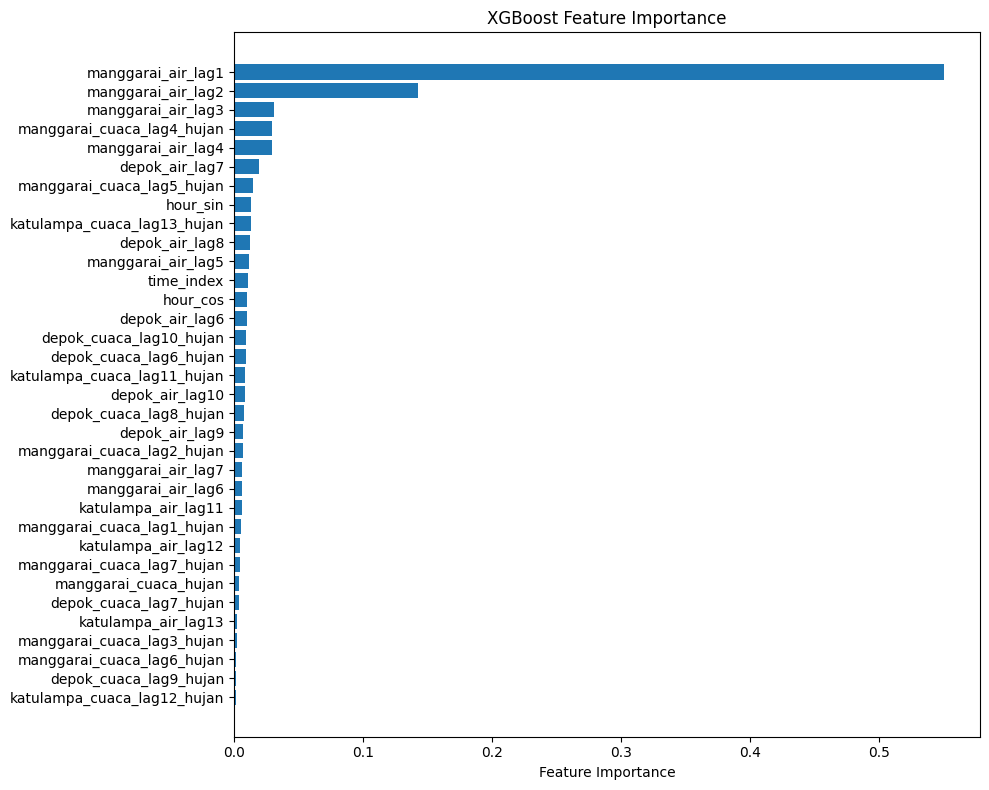

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nMost Important Features:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 8))
top_features = feature_importance
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

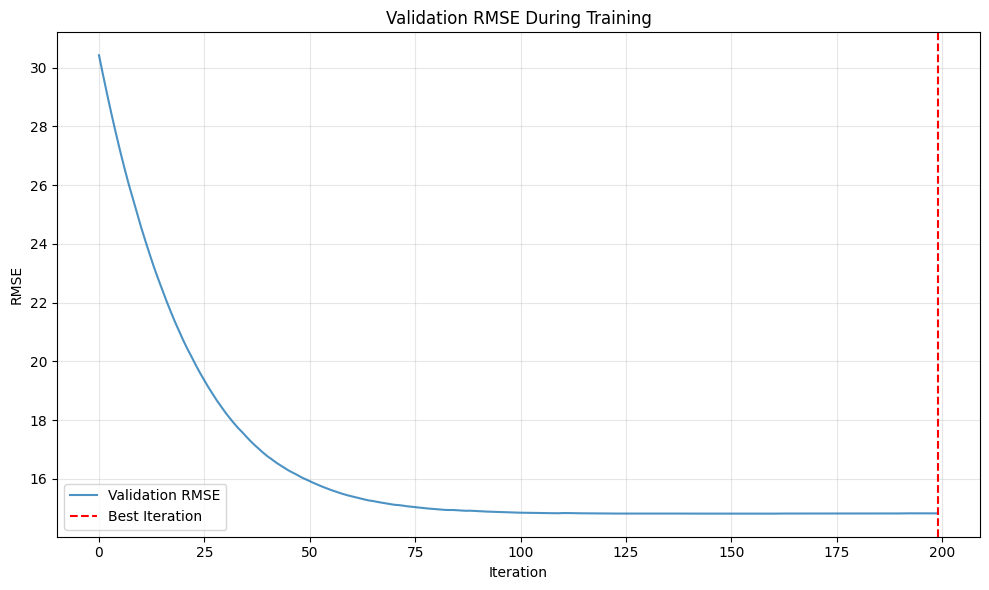

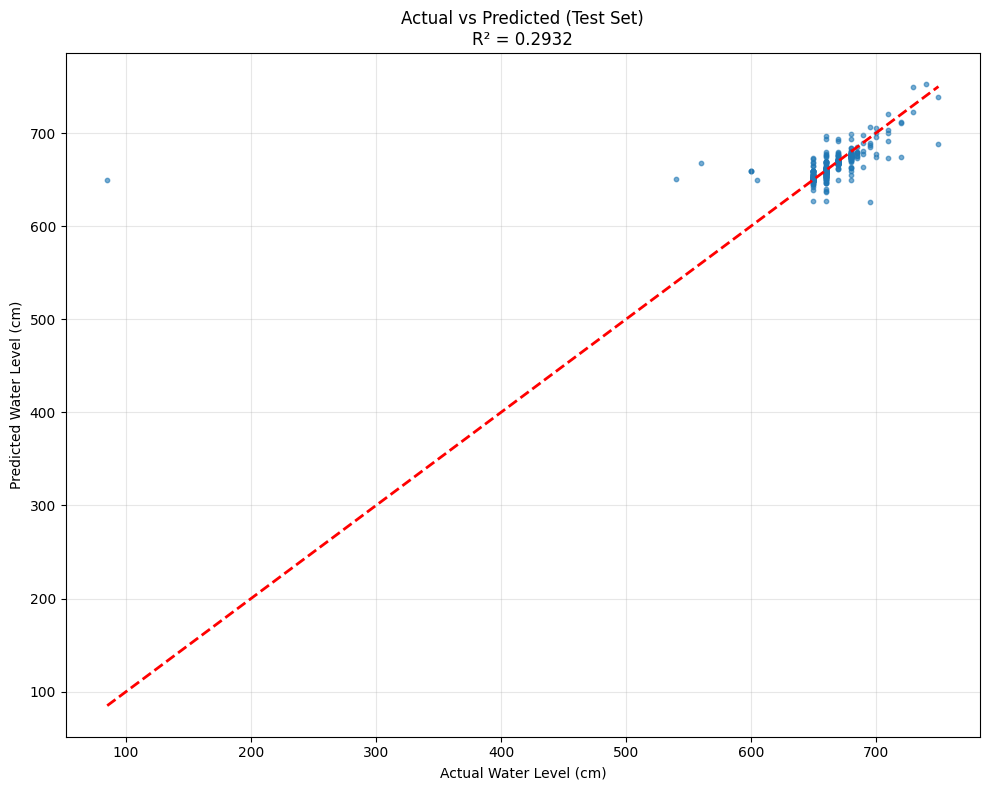

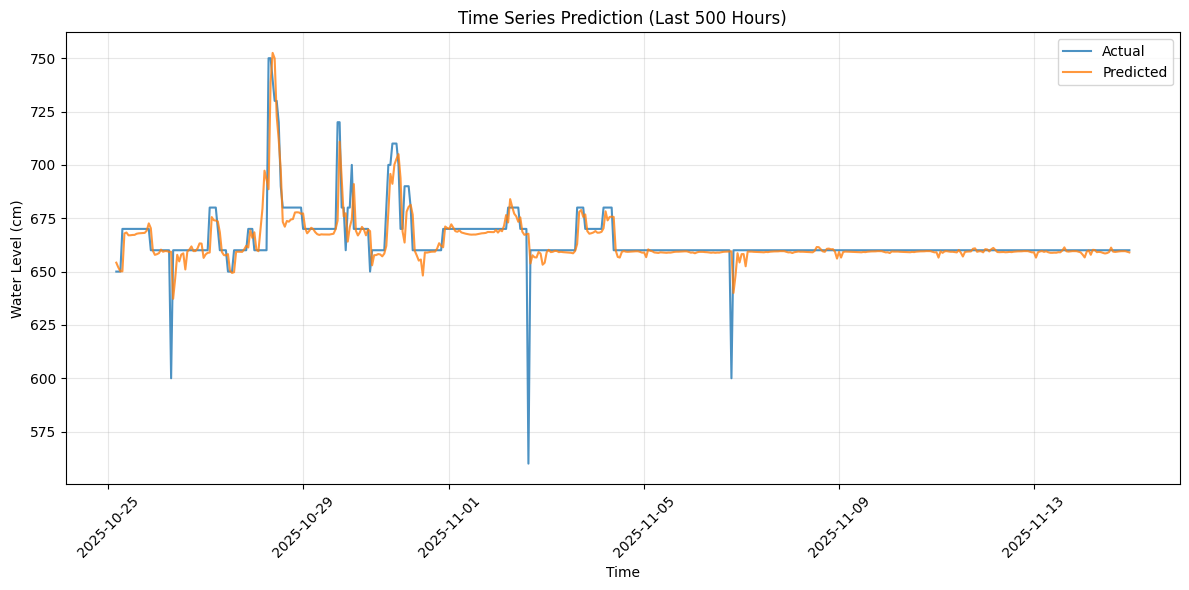

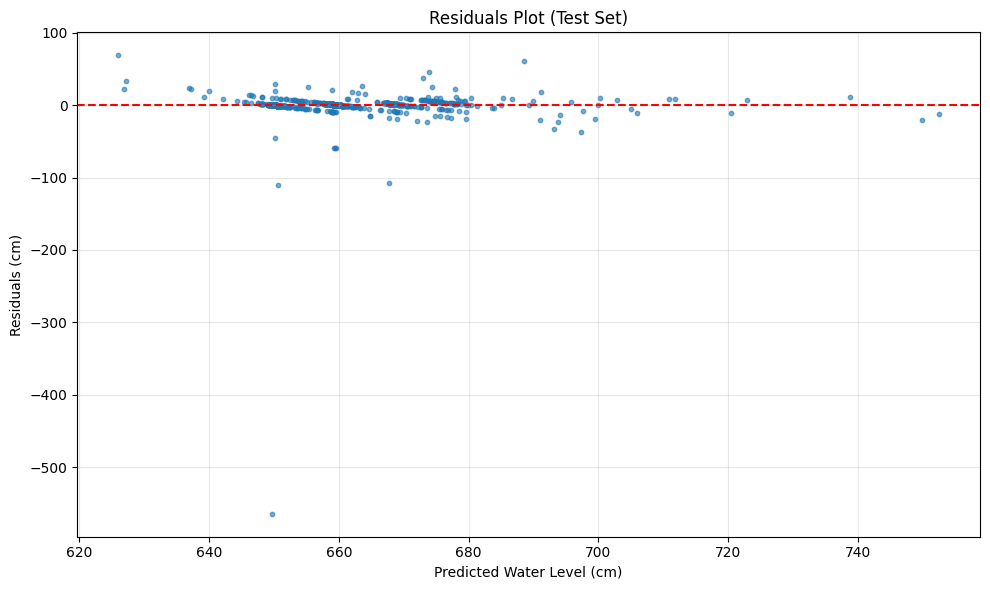

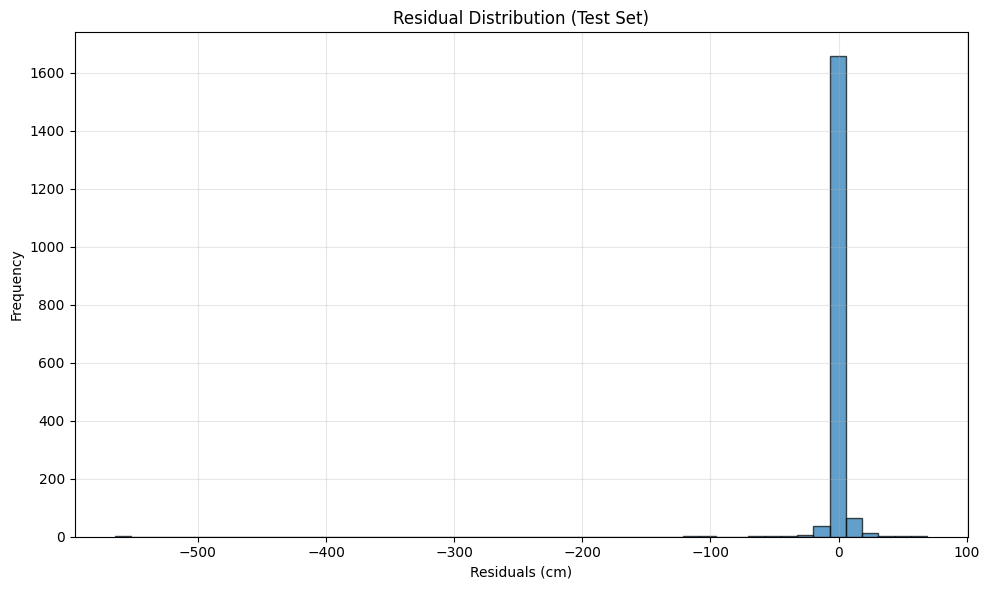

In [ ]:
# --- PLOT 1: Training Validation Curve ---
plt.figure(figsize=(10, 6))
eval_results = model.evals_result()
if 'validation_0' in eval_results:
    plt.plot(eval_results['validation_0']['rmse'], label='Validation RMSE', alpha=0.8)
    # XGBoost best_iteration hanya tersedia jika early_stopping_rounds diaktifkan
    # Jika tidak, kita ambil iterasi terakhir
    best_iter = model.best_iteration if hasattr(model, 'best_iteration') else final_params['n_estimators'] - 1
    
    plt.axvline(x=best_iter, color='red', linestyle='--', label='Best Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('RMSE')
    plt.title('Validation RMSE During Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Training progress\nnot available',
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Training Progress')

plt.tight_layout()
plt.show()

# --- PLOT 2: Actual vs Predicted (Test Set) ---
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test_pred, alpha=0.6, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Water Level (cm)')
plt.ylabel('Predicted Water Level (cm)')
plt.title(f'Actual vs Predicted (Test Set)\nR² = {test_r2:.4f}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PLOT 3: Time Series Prediction (Last 500 Points) ---
plt.figure(figsize=(12, 6))
plot_points = min(500, len(y_test))
plt.plot(y_test.tail(plot_points), label='Actual', linewidth=1.5, alpha=0.8)
plt.plot(y_test.tail(plot_points).index, test_pred[-plot_points:],
         label='Predicted', linewidth=1.5, alpha=0.8)
plt.xlabel('Time')
plt.ylabel('Water Level (cm)')
plt.title(f'Time Series Prediction (Last {plot_points} Hours)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- PLOT 4: Residuals Plot ---
plt.figure(figsize=(10, 6))
plt.scatter(test_pred, residuals_test, alpha=0.6, s=10)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Water Level (cm)')
plt.ylabel('Residuals (cm)')
plt.title('Residuals Plot (Test Set)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PLOT 5: Residuals Histogram ---
plt.figure(figsize=(10, 6))
plt.hist(residuals_test, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals (cm)')
plt.ylabel('Frequency')
plt.title('Residual Distribution (Test Set)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

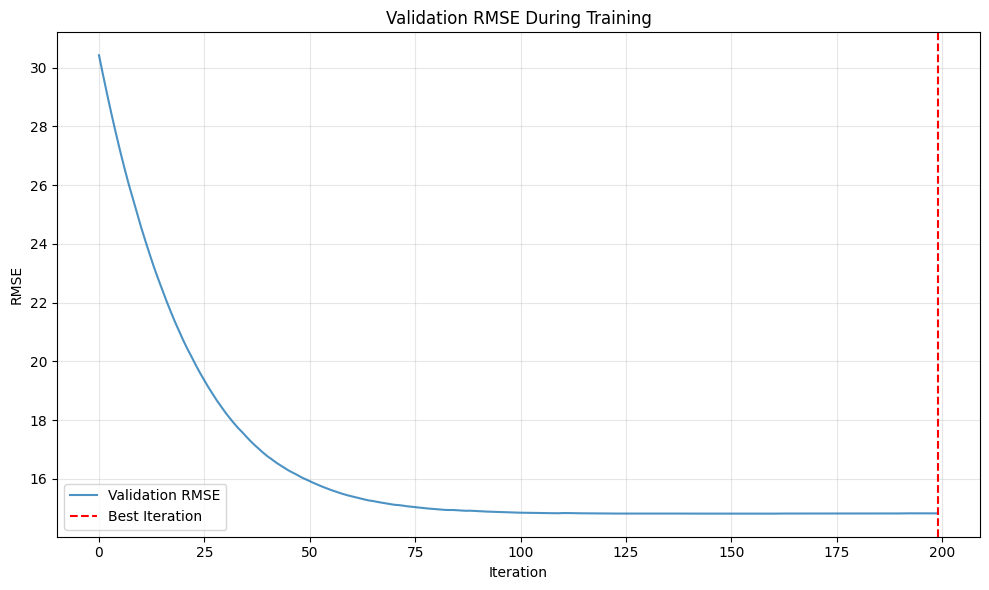

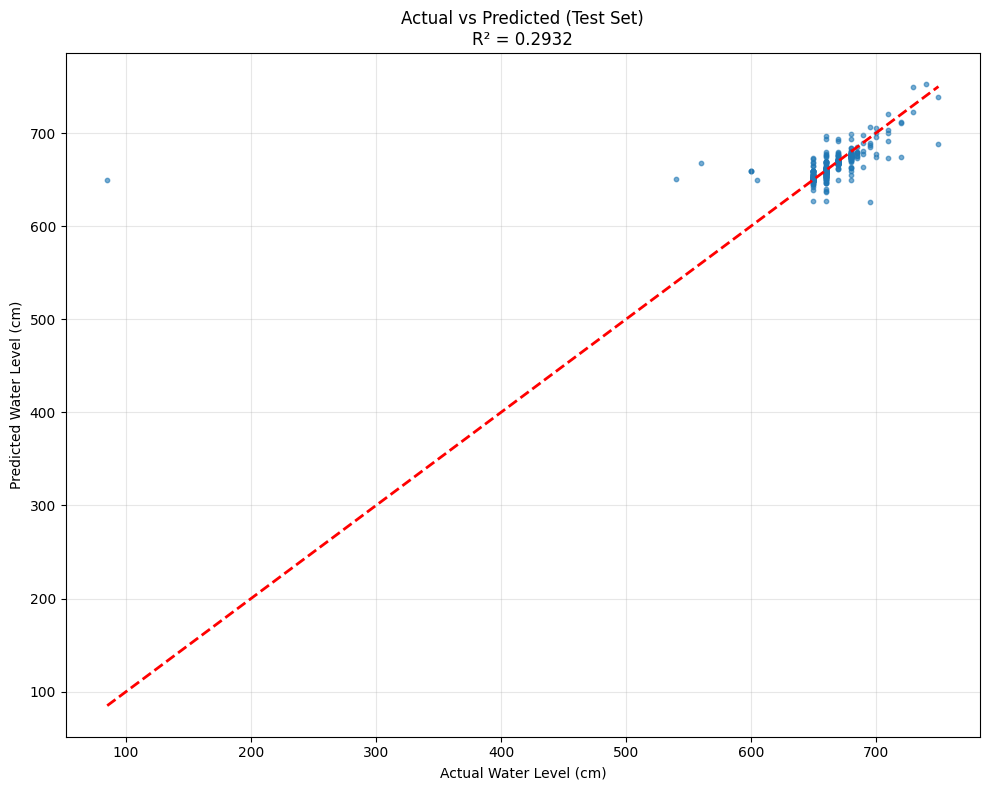

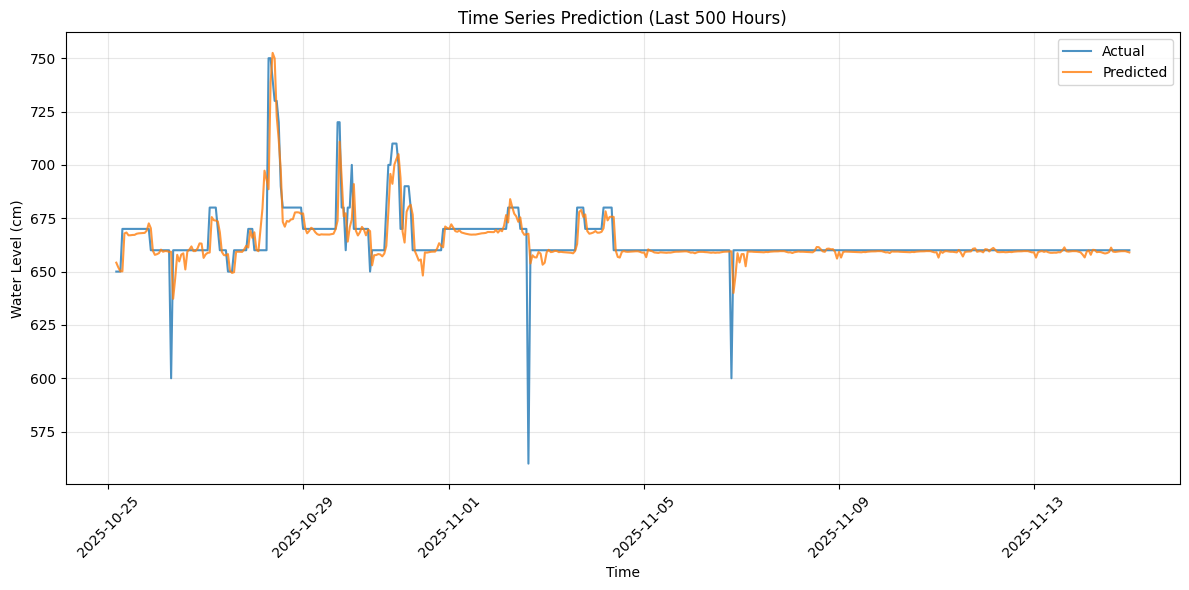

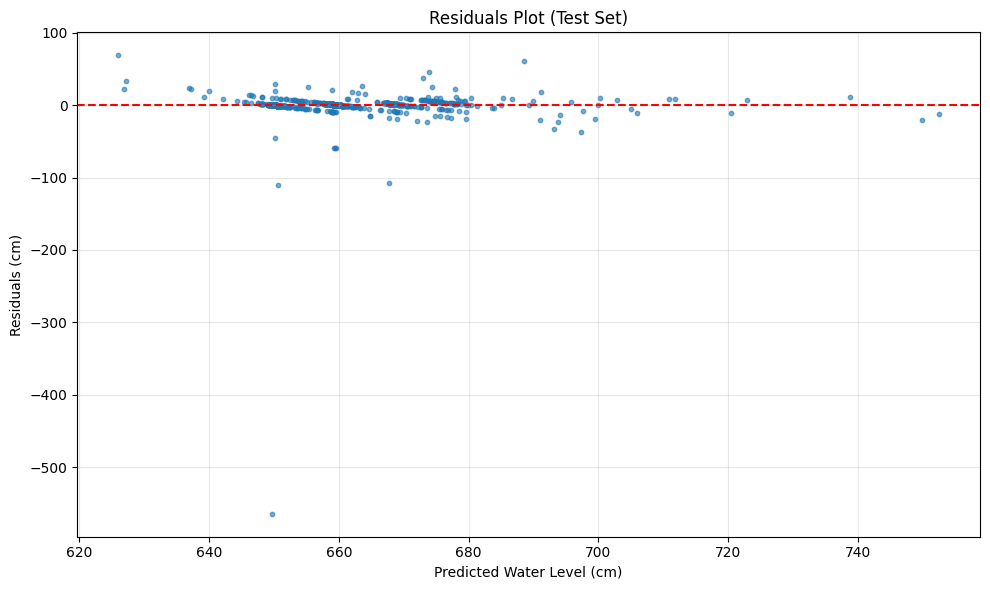

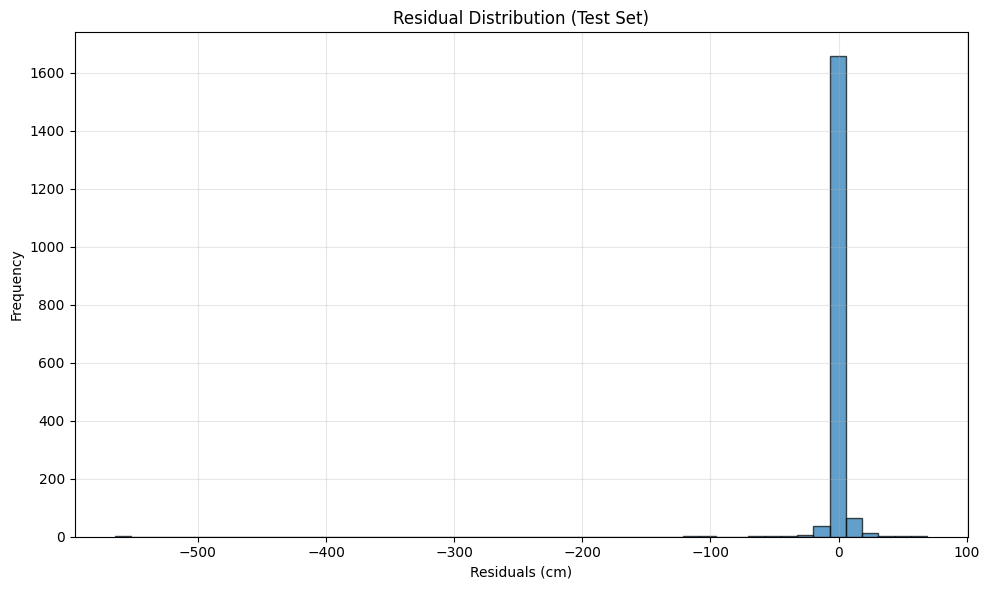

In [ ]:
# --- PLOT 1: Training Validation Curve ---
plt.figure(figsize=(10, 6))
eval_results = model.evals_result()
if 'validation_0' in eval_results:
    plt.plot(eval_results['validation_0']['rmse'], label='Validation RMSE', alpha=0.8)
    # XGBoost best_iteration hanya tersedia jika early_stopping_rounds diaktifkan
    # Jika tidak, kita ambil iterasi terakhir
    best_iter = model.best_iteration if hasattr(model, 'best_iteration') else final_params['n_estimators'] - 1
    
    plt.axvline(x=best_iter, color='red', linestyle='--', label='Best Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('RMSE')
    plt.title('Validation RMSE During Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Training progress\nnot available',
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Training Progress')

plt.tight_layout()
plt.show()

# --- PLOT 2: Actual vs Predicted (Test Set) ---
plt.figure(figsize=(10, 8))
plt.scatter(y_test, test_pred, alpha=0.6, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Water Level (cm)')
plt.ylabel('Predicted Water Level (cm)')
plt.title(f'Actual vs Predicted (Test Set)\nR² = {test_r2:.4f}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PLOT 3: Time Series Prediction (Last 500 Points) ---
plt.figure(figsize=(12, 6))
plot_points = min(500, len(y_test))
plt.plot(y_test.tail(plot_points), label='Actual', linewidth=1.5, alpha=0.8)
plt.plot(y_test.tail(plot_points).index, test_pred[-plot_points:],
         label='Predicted', linewidth=1.5, alpha=0.8)
plt.xlabel('Time')
plt.ylabel('Water Level (cm)')
plt.title(f'Time Series Prediction (Last {plot_points} Hours)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- PLOT 4: Residuals Plot ---
plt.figure(figsize=(10, 6))
plt.scatter(test_pred, residuals_test, alpha=0.6, s=10)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Water Level (cm)')
plt.ylabel('Residuals (cm)')
plt.title('Residuals Plot (Test Set)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- PLOT 5: Residuals Histogram ---
plt.figure(figsize=(10, 6))
plt.hist(residuals_test, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals (cm)')
plt.ylabel('Frequency')
plt.title('Residual Distribution (Test Set)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Reduced Dataset

In [ ]:
exog_columns = [
    'manggarai_air_lag1', 'manggarai_air_lag2','manggarai_air_lag3','manggarai_air_lag4','manggarai_air_lag5','manggarai_cuaca_lag4_hujan', 'manggarai_cuaca_lag5_hujan', 'depok_air_lag7','depok_air_lag8', 'hour_sin', 'hour_cos', 'time_index', 'katulampa_cuaca_lag13_hujan'
]

X_train_reduced = X_train[exog_columns]
X_test_reduced = X_test[exog_columns]

print(X_train_reduced.head())
print(X_test_reduced.head())

                     manggarai_air_lag1  manggarai_air_lag2  \
Tanggal                                                       
2021-10-17 00:00:00               565.0               565.0   
2021-10-17 01:00:00               590.0               565.0   
2021-10-17 02:00:00               575.0               590.0   
2021-10-17 03:00:00               570.0               575.0   
2021-10-17 04:00:00               565.0               570.0   

                     manggarai_air_lag3  manggarai_air_lag4  \
Tanggal                                                       
2021-10-17 00:00:00               565.0               600.0   
2021-10-17 01:00:00               565.0               565.0   
2021-10-17 02:00:00               565.0               565.0   
2021-10-17 03:00:00               590.0               565.0   
2021-10-17 04:00:00               575.0               590.0   

                     manggarai_air_lag5  manggarai_cuaca_lag4_hujan  \
Tanggal                                      

In [ ]:
baseline_start = datetime.now()
baseline_model = xgb.XGBRegressor(**fixed_params)
baseline_model.fit(X_train, y_train)
baseline_time = datetime.now() - baseline_start

baseline_train_pred = baseline_model.predict(X_train)
baseline_test_pred = baseline_model.predict(X_test)

# Calculate metrics for training set
baseline_train_rmse = np.sqrt(mean_squared_error(y_train, baseline_train_pred))
baseline_train_mae = mean_absolute_error(y_train, baseline_train_pred)
baseline_train_r2 = r2_score(y_train, baseline_train_pred)
baseline_train_mape = mean_absolute_percentage_error(y_train, baseline_train_pred)

# Calculate metrics for test set
baseline_test_rmse = np.sqrt(mean_squared_error(y_test, baseline_test_pred))
baseline_test_mae = mean_absolute_error(y_test, baseline_test_pred)
baseline_test_r2 = r2_score(y_test, baseline_test_pred)
baseline_test_mape = mean_absolute_percentage_error(y_test, baseline_test_pred)

print(f"Baseline completed in {baseline_time}")

print(f"Baseline Train RMSE: {baseline_train_rmse:.4f}")
print(f"Baseline Train MAE: {baseline_train_mae:.4f}")
print(f"Baseline Train R2: {baseline_train_r2:.4f}")
print(f"Baseline Train MAPE: {baseline_train_mape:.4f}")

print(f"Baseline Test RMSE: {baseline_test_rmse:.4f}")
print(f"Baseline Test MAE: {baseline_test_mae:.4f}")
print(f"Baseline Test R2: {baseline_test_r2:.4f}")
print(f"Baseline Test MAPE: {baseline_test_mape:.4f}")

Baseline completed in 0:00:01.914691
Baseline Train RMSE: 10.4458
Baseline Train MAE: 2.9625
Baseline Train R2: 0.9470
Baseline Train MAPE: 0.0085
Baseline Test RMSE: 29.1520
Baseline Test MAE: 8.9603
Baseline Test R2: -0.0155
Baseline Test MAPE: 0.0259


# Grid Search

In [ ]:
param_grid = {
    'max_depth': [4, 6, 8],
    'min_child_weight': [1, 3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'learning_rate': [0.05, 0.1, 0.15],
    'n_estimators': [300, 500],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [0.5, 1.0]
}

In [ ]:
combinations = 1
for param, values in param_grid.items():
    combinations *= len(values)
    print(f"  {param}: {values}")

print(f"\nTotal combinations: {combinations}")

  max_depth: [4, 6, 8]
  min_child_weight: [1, 3]
  subsample: [0.8, 1.0]
  colsample_bytree: [0.8, 1.0]
  learning_rate: [0.05, 0.1, 0.15]
  n_estimators: [300, 500]
  reg_alpha: [0.1, 0.5]
  reg_lambda: [0.5, 1.0]

Total combinations: 576


In [ ]:
# Run grid search
base_model = xgb.XGBRegressor(**fixed_params)
grid_start = datetime.now()

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=2
)

grid_search.fit(X_train, y_train)
grid_time = datetime.now() - grid_start

Fitting 3 folds for each of 576 candidates, totalling 1728 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=300, reg_alpha=0.1, reg_lambda=0.5, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=300, reg_alpha=0.1, reg_lambda=0.5, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=300, reg_alpha=0.1, reg_lambda=0.5, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=300, reg_alpha=0.1, reg_lambda=0.5, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=300, reg_alpha=0.1, reg_lambda=0.5, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=300,

In [ ]:
print(f"Grid search time: {grid_time}")
print(f"Best grid CV score: {-grid_search.best_score_:.4f}")
print(f"Best grid parameters: {grid_search.best_params_}")

Grid search time: 0:22:28.614642
Best grid CV score: 16.8175
Best grid parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'n_estimators': 300, 'reg_alpha': 0.5, 'reg_lambda': 1.0, 'subsample': 0.8}


In [ ]:
grid_results_df = pd.DataFrame(grid_search.cv_results_)
grid_results_df.to_csv('08 grid_search_results.csv', index=False)

## Best Grid Search Level 2 Model Performance

In [ ]:
final_params = {**fixed_params, **grid_search.best_params_, 'early_stopping_rounds': 50}

print("Final parameters:")
for key, value in final_params.items():
    print(f"  {key}: {value}")

Final parameters:
  tree_method: gpu_hist
  gpu_id: 0
  objective: reg:squarederror
  eval_metric: rmse
  random_state: 42
  n_jobs: -1
  verbosity: 1
  colsample_bytree: 0.8
  learning_rate: 0.05
  max_depth: 4
  min_child_weight: 3
  n_estimators: 300
  reg_alpha: 0.5
  reg_lambda: 1.0
  subsample: 0.8
  early_stopping_rounds: 50


In [ ]:
# Train final model
final_start = datetime.now()
final_model = xgb.XGBRegressor(**final_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
final_training_time = datetime.now() - final_start

print(f"\nTraining completed in: {training_time}")
print(f"Best iteration: {model.best_iteration}")
print(f"Best score: {model.best_score:.4f}")


Training completed in: 0:00:00.826444
Best iteration: 27
Best score: 24.1459


In [ ]:
# Make predictions
train_pred = final_model.predict(X_train)
test_pred = final_model.predict(X_test)

# Calculate metrics for training set
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_mae = mean_absolute_error(y_train, train_pred)
train_r2 = r2_score(y_train, train_pred)
train_mape = mean_absolute_percentage_error(y_train, train_pred)

# Calculate metrics for test set
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_mae = mean_absolute_error(y_test, test_pred)
test_r2 = r2_score(y_test, test_pred)
test_mape = mean_absolute_percentage_error(y_test, test_pred)

print("TRAINING SET METRICS:")
print(f"  RMSE: {train_rmse:.4f} cm")
print(f"  MAE:  {train_mae:.4f} cm")
print(f"  R²:   {train_r2:.4f}")
print(f"  MAPE: {train_mape:.2f}%")

print("\nTEST SET METRICS:")
print(f"  RMSE: {test_rmse:.4f} cm")
print(f"  MAE:  {test_mae:.4f} cm")
print(f"  R²:   {test_r2:.4f}")
print(f"  MAPE: {test_mape:.2f}%")

TRAINING SET METRICS:
  RMSE: 16.5171 cm
  MAE:  4.9175 cm
  R²:   0.8676
  MAPE: 0.02%

TEST SET METRICS:
  RMSE: 24.1184 cm
  MAE:  5.3663 cm
  R²:   0.3049
  MAPE: 0.02%


In [ ]:
final_model.save_model('final_optimized_xgboost_model.json')